In [13]:
# import setup
from src.utils.my_plotting import new_fig, finish_fig, plot_corr_mat

In [14]:
import polars as pl
from polars import col as c
import matplotlib.pyplot as plt
from scipy import stats

In [15]:
INPUT = '../data/processed/features.parquet'

In [33]:
lf = pl.scan_parquet(INPUT).sort(['ticker', 'date'])

In [36]:
lf.describe()

statistic,ticker,date,open,high,low,close,volume,logret,mkt_logret,beta60,beta252,mom5,mom10,mom20,mom60,mom120,mom252,std5,std10,std20,std60,std120,std252,dollar_volume,log_adv5,log_adv10,log_adv20,log_adv60,log_adv120,log_adv252
str,str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""count""","""2913104""","""2913104""",2.913104e6,2.913104e6,2.913104e6,2.913104e6,2.913104e6,2.912603e6,2.91276e6,2.883119e6,2.787389e6,2.910599e6,2.908094e6,2.903088e6,2.883119e6,2.853179e6,2.787389e6,2.910599e6,2.908094e6,2.903088e6,2.883119e6,2.853179e6,2.787389e6,2.913104e6,2.9111e6,2.908595e6,2.903588e6,2.883618e6,2.853678e6,2.787887e6
"""null_count""","""0""","""0""",0.0,0.0,0.0,0.0,0.0,501.0,344.0,29985.0,125715.0,2505.0,5010.0,10016.0,29985.0,59925.0,125715.0,2505.0,5010.0,10016.0,29985.0,59925.0,125715.0,0.0,2004.0,4509.0,9516.0,29486.0,59426.0,125217.0
"""mean""",null,"""2014-01-26 21:48:06.659453""",85.193656,86.202688,84.162924,75.058989,8.5497e6,0.000448,0.000447,1.000519,1.000658,0.003553,0.006972,0.013877,0.041123,0.083147,0.182225,0.01805,0.018894,0.019415,0.019991,0.020221,0.020444,2.7529e8,18.246543,18.263562,18.277791,18.295696,18.305484,18.319412
"""std""",null,null,198.496441,200.888138,196.116668,195.735854,4.7510e7,0.023523,0.01261,0.527723,0.429399,0.051117,0.070702,0.099513,0.172853,0.264314,0.536179,0.015319,0.014176,0.01332,0.012237,0.011591,0.010838,1.1697e9,1.620138,1.604692,1.590408,1.567035,1.547257,1.510771
"""min""","""A""","""2000-01-03""",0.030208,0.030521,0.026979,0.030521,20.0,-1.141076,-0.139547,-3.695049,-0.947162,-0.882857,-0.909212,-0.898093,-0.95309,-0.981547,-0.992031,0.0,0.0,0.001027,0.001751,0.002597,0.003873,298.6624,6.812448,7.347286,7.79504,8.948253,9.274314,9.861517
"""25%""",null,"""2007-09-21""",23.65,23.969999,23.3125,16.262363,957800.0,-0.009096,-0.004877,0.66358,0.716978,-0.019344,-0.025931,-0.034617,-0.046911,-0.049043,-0.040177,0.009106,0.010505,0.011408,0.012486,0.012953,0.013431,3.4234e7,17.416991,17.442276,17.464255,17.492899,17.508801,17.538485
"""50%""",null,"""2014-06-20""",45.690529,46.23,45.150002,34.339821,2.243271e6,0.000599,0.000873,0.954848,0.966323,0.003495,0.006857,0.013374,0.037201,0.069332,0.137468,0.013975,0.015088,0.015838,0.016661,0.017048,0.01755,9.5211e7,18.417135,18.434267,18.44816,18.462442,18.465682,18.472671
"""75%""",null,"""2020-08-20""",89.68,90.660004,88.660004,77.203262,5.453041e6,0.010257,0.006411,1.26955,1.231925,0.025948,0.039118,0.060105,0.120462,0.189248,0.327515,0.021783,0.022437,0.022861,0.023341,0.023648,0.024133,2.2698e8,19.259269,19.264643,19.268232,19.269551,19.266315,19.257238
"""max""","""ZTS""","""2026-07-08""",9914.169922,9964.769531,9794.0,9924.400391,9.2309e9,0.704868,0.105833,11.656695,4.748166,3.715908,4.352941,5.252941,6.789738,14.338714,64.339399,0.556048,0.472352,0.341565,0.211346,0.16879,0.139609,1.5438e11,25.111815,24.974199,24.846847,24.528483,24.505749,24.386849


## Random ticker -  visual inspection

In [47]:
df = lf.filter(
    c('ticker').is_in( c('ticker').unique().sample(1).implode() )
).collect().to_pandas().set_index('date')

In [8]:
df = lf.filter(
    c('ticker') == 'AAPL'
).collect().to_pandas().set_index('date')

Note that our returns start in 2000, so there is less than 500 tickers then. Since we infer the market returns using the present tickers, there is much more volatility and covariance around 2000. This is a big look-ahead bias that obviously needs to be dealt with differently in produciton.

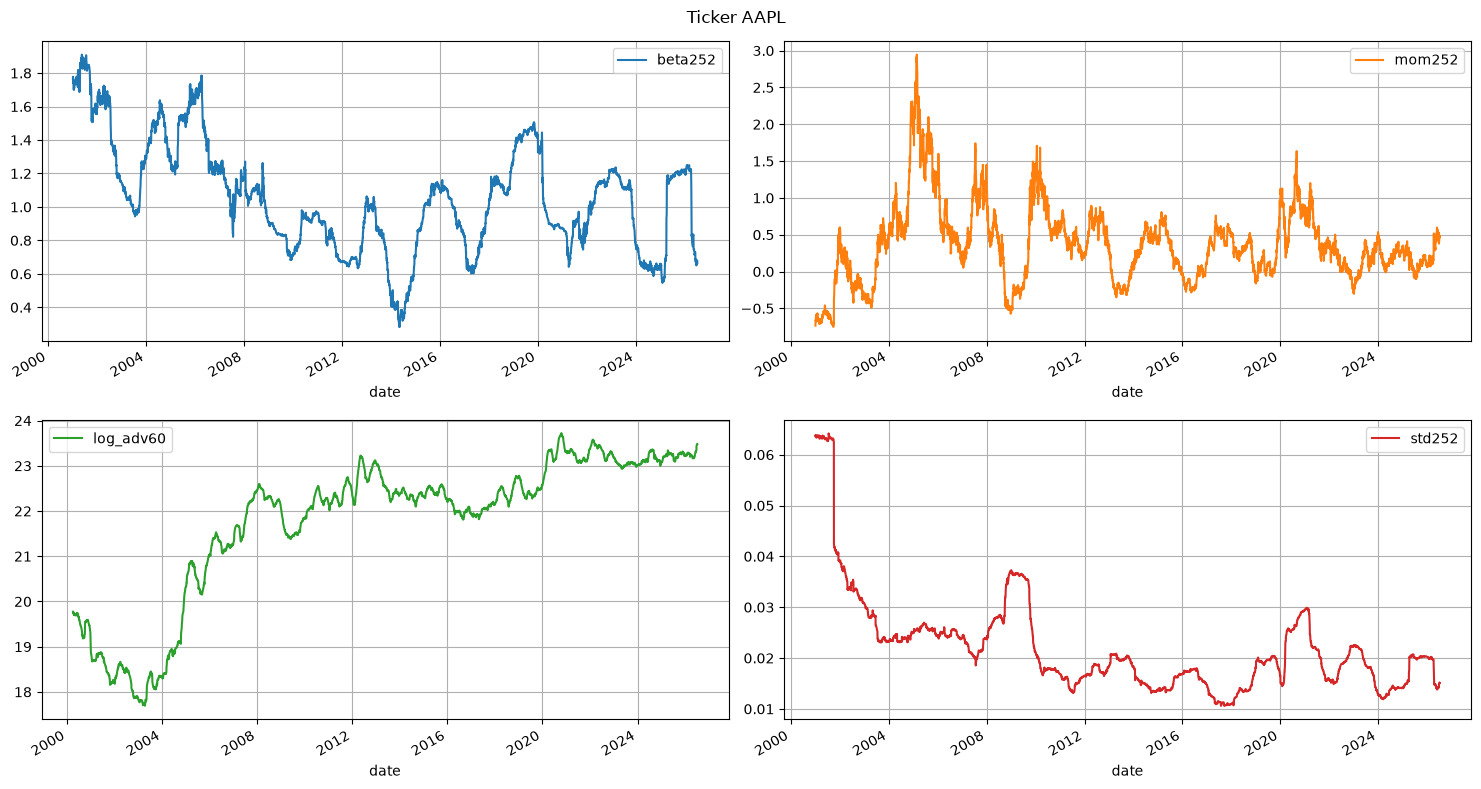

In [10]:
feat = 'beta252'
f, ax = plt.subplots(2, 2, figsize=(15, 8))
df.plot(y='beta252', ax=ax[0, 0])
df.plot(y='mom252', ax=ax[0, 1], color='C1')
df.plot(y='log_adv60', ax=ax[1, 0], color='C2')
df.plot(y='std252', ax=ax[1, 1], color='C3')
for ax__ in ax.flatten():
    ax__.grid()
f.suptitle('Ticker ' + df['ticker'].iloc[0])
plt.tight_layout()
# finish_fig(ax, yl=feat, title = df['ticker'].iloc[0] + ' - ' + feat)

## Null count

In [7]:
lf.null_count().collect()

ticker,date,open,high,low,close,volume,logret,mom5,mom10,mom20,mom60,mom120,mom252,std5,std10,std20,std60,std120,std252,dollar_volume,adv5,adv10,adv20,adv60,adv120,adv252
u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32
0,0,0,0,0,0,0,501,2505,5010,10016,29985,59925,125715,2004,4509,9516,29486,59426,125217,0,2004,4509,9516,29486,59426,125217


## Average number of observations per ticker

In [ ]:
lf.group_by('ticker').agg()

## Distributions

In [37]:
mom20 = ( 
    lf
    .select('mom20')
    .drop_nulls()
    .collect()
    .to_pandas()
)
std20 = ( 
    lf
    .select('std20')
    .drop_nulls()
    .collect()
    .to_pandas()
)
adv20 = ( 
    lf
    .select('log_adv20')
    .drop_nulls()
    .collect()
    .to_pandas()
)
beta252 = ( 
    lf
    .select('beta252')
    .drop_nulls()
    .collect()
    .to_pandas()
)

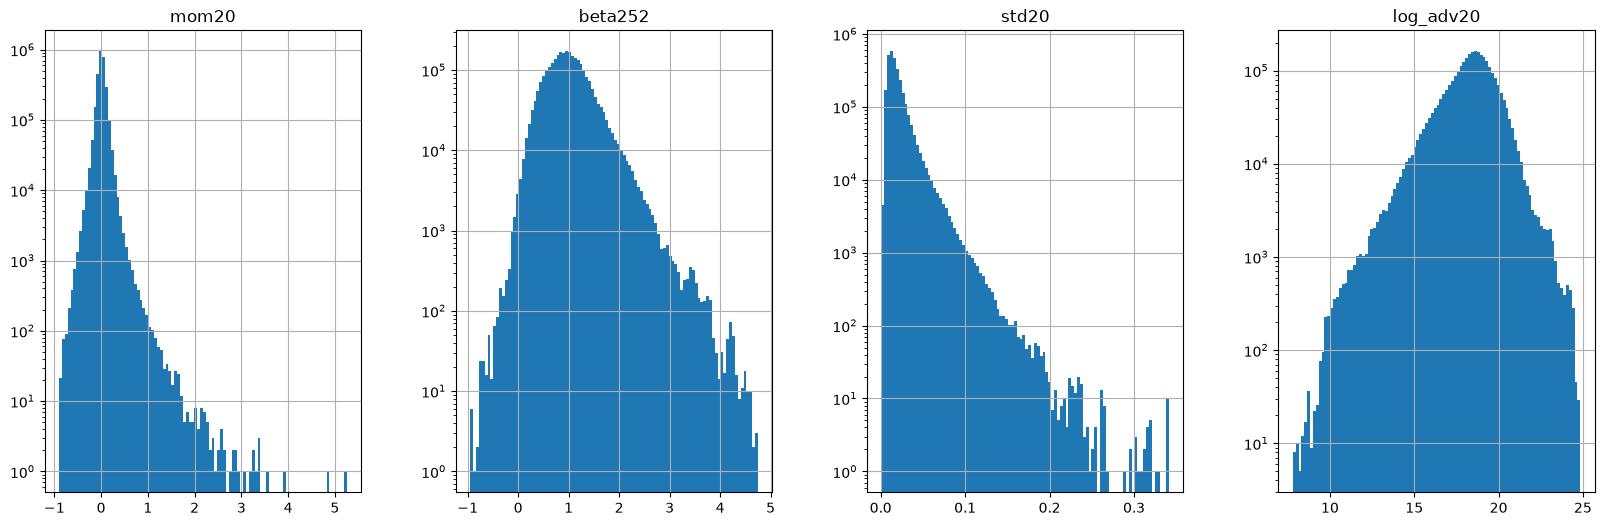

In [38]:
f, ax = plt.subplots(1, 4, figsize=(20, 6))
mom20.hist(bins=100, ax=ax[0], log=True)
beta252.hist(bins=100, ax=ax[1], log=True)
std20.hist(bins=100, ax=ax[2], log=True)
adv20.hist(bins=100, ax=ax[3], log=True);

In [8]:
feat = 'mom20'
(
    lf
    .select(
        c(feat).quantile(0.01).alias('Q1%'),
        c(feat).median().alias('median'),
        c(feat).quantile(0.99).alias('Q99%')
    )
    .collect()
)

Q1%,median,Q99%
f64,f64,f64
-0.252259,0.013358,0.293769


## Correlation

In [39]:
Cmat = (
    lf
    .select(['mom5', 'mom20', 'mom120', 'mom252', 
             'std5', 'std20', 'std120', 'std252', 
             'beta60', 'beta252',
             'log_adv5', 'log_adv20', 'log_adv120', 'log_adv252'])
    .drop_nulls()
    .collect()
    .to_pandas()
).corr()

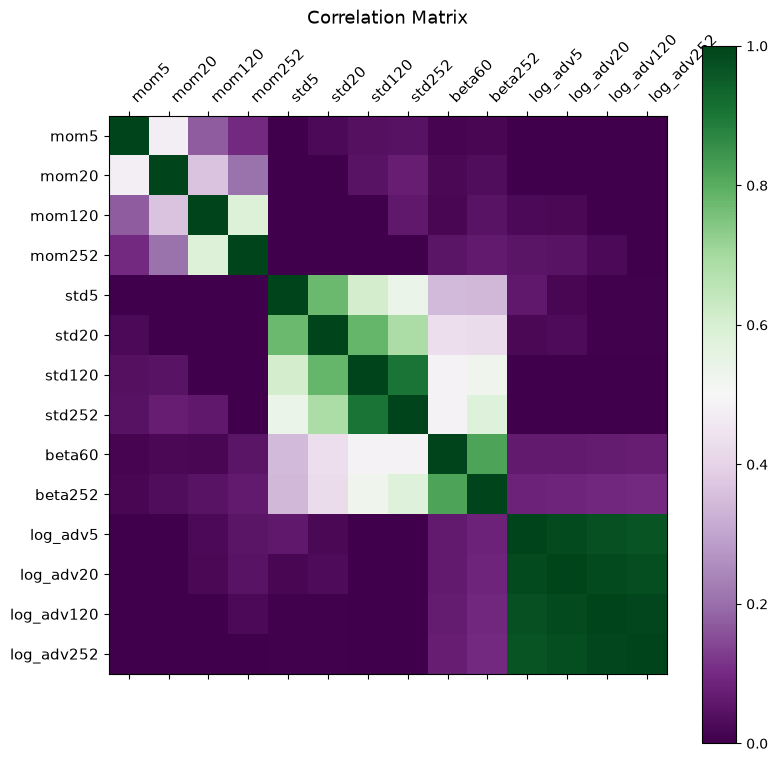

In [40]:
plot_corr_mat(Cmat, vmin=0, fs=(9, 9))

## Stability over time

In [47]:
df_mom = (
    lf
    .sort('date')
    .group_by_dynamic(
        'date',
        every='6mo'
    )
    .agg(
        c('mom20').mean().alias('mom_mean'),
        c('mom20').std().alias('mom_std'),
    )
).collect().to_pandas().set_index('date')
df_std = (
    lf
    .sort('date')
    .group_by_dynamic(
        'date',
        every='6mo'
    )
    .agg(
        c('std20').mean().alias('std_mean'),
        c('std20').std().alias('std_std'),
    )
).collect().to_pandas().set_index('date')

df_beta = (
    lf
    .sort('date')
    .group_by_dynamic(
        'date',
        every='6mo'
    )
    .agg(
        c('beta60').mean().alias('beta_mean'),
        c('beta60').std().alias('beta_std'),
    )
).collect().to_pandas().set_index('date')


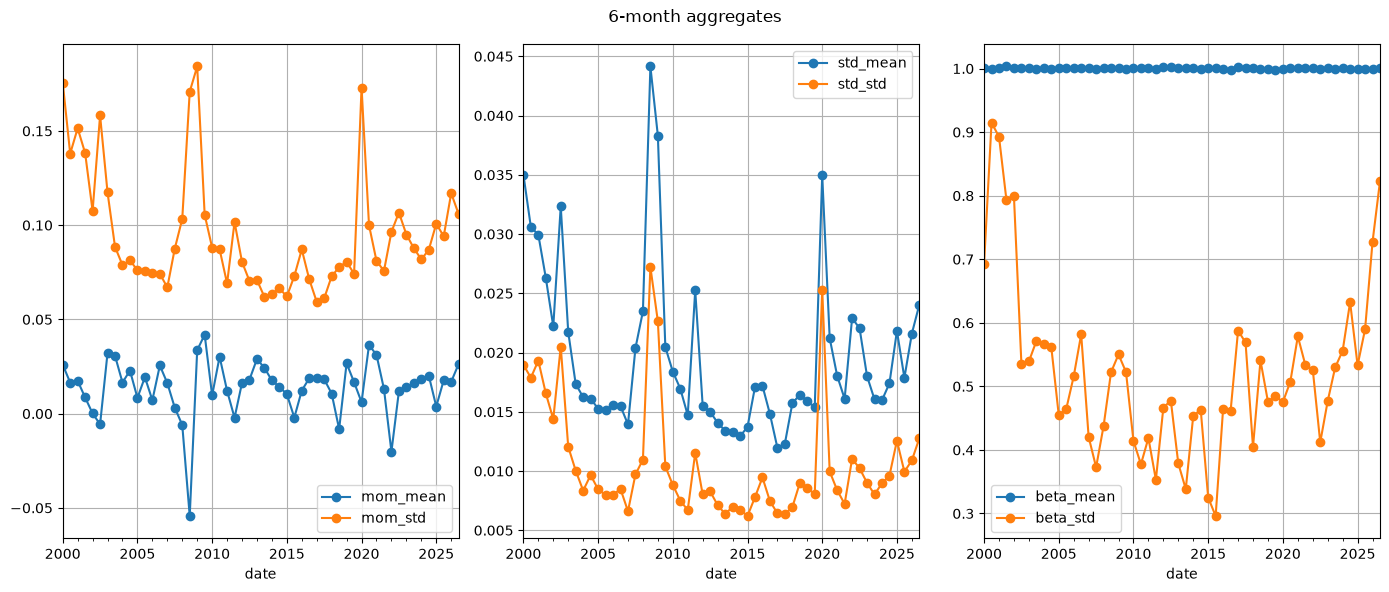

In [52]:
f, ax = plt.subplots(1, 3, figsize=(14, 6))
df_mom.plot(ax=ax[0], marker='o')
df_std.plot(ax=ax[1], marker='o')
df_beta.plot(ax=ax[2], marker='o')
ax[0].grid();ax[1].grid();ax[2].grid();f.suptitle('6-month aggregates');plt.tight_layout();

## QQ plots

In [44]:
df = (
    lf
    .select(['mom5', 'mom20', 'mom120', 'mom252', 
             'std5', 'std20', 'std120', 'std252', 
             'log_adv5', 'log_adv20', 'log_adv120', 'log_adv252'])
    .drop_nulls()
    .collect()
    .to_pandas()
)

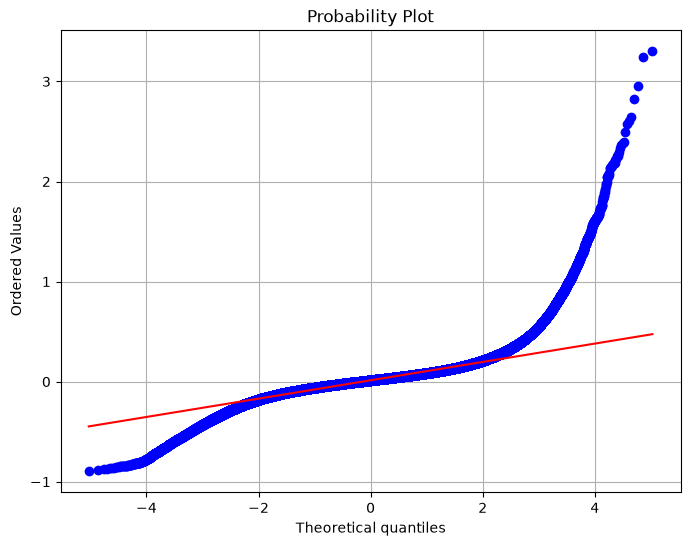

In [45]:
f, ax = new_fig()
stats.probplot(df['mom20'], plot=plt)
plt.grid()

## mom20 vs log-returns

In [59]:
df = (
    lf
    .select(
        c('date'), 
        (
            c('logret')
            .shift(-1)
            .over('ticker')
            .alias('next_logret')
        ), 
        c('mom20')
    )
    .drop_nulls()
    .collect()
    .to_pandas()
    .set_index('date')
)

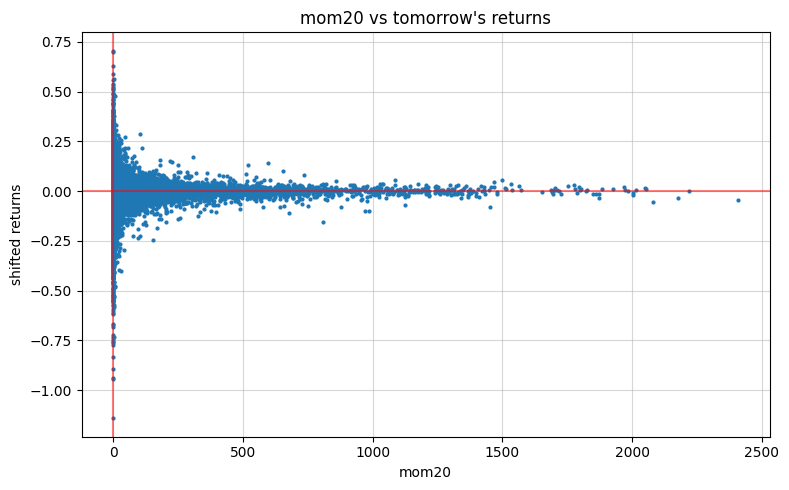

In [60]:
f, ax = new_fig(fs=(8, 5))
plt.plot(df['mom20'], df['next_logret'], 'o', markersize=2)
plt.axhline(0, color='red', alpha=0.5);plt.axvline(0, color='red', alpha=0.5)
finish_fig(ax, xl='mom20', yl='shifted returns', title='mom20 vs tomorrow\'s returns')